In [1]:
# PASSO 1 - abrir netCDF

import xarray as xr
import pandas as pd #indicado no inicio

ds = xr.open_dataset("pr_20010101_20240320_BR-DWGD_UFES_UTEXAS_v_3.2.3.nc")

print(ds)

print(ds.pr)

# PASSO 2 - definir area de interesse (vale do taquari) e data

lat_vale_taquari = -29.4669
lon_vale_taquari = -51.9608
data = '2023-09-04'

latitude = lat_vale_taquari
longitude = lon_vale_taquari

# PASSO 3 - selecionar dados com a interpolação bilinear

net_chuva_bilinear = ds.pr.sel(time=data).interp(
    latitude=lat_vale_taquari,
    longitude=lon_vale_taquari,
    method='linear'
)

valor_chuva = net_chuva_bilinear.values.item()
print(f'Precipitação no vale do taquari em {data}: {valor_chuva:.2f} mm')

# PASSO 4 - lista de estações do analise estacoes.py

lista_estacoes = [
    {"nome": "Bento Gonçalves", "lat": -29.1642, "lon": -51.5312},
    {"nome": "Caxias do Sul", "lat": -29.1764, "lon": -51.1767},
    {"nome": "Santa Maria", "lat": -29.7114, "lon": -53.7144}
]

data_inicio = "2023-09-01"
data_fim = "2023-09-07"

print(f"extraindo dados (Padrão 10 UTC às 10 UTC)")
print("-" * 50)

# PASSO 5 - loop de extração atualizado

todos_resultados = []

recorte_temporal = ds.pr.sel(time=slice(data_inicio, data_fim)) #fora do loop

for estacao in lista_estacoes:
    serie_chuva = recorte_temporal.interp(
        latitude=estacao['lat'],
        longitude=estacao['lon'],
        method='linear'
    )

    df_temp = serie_chuva.to_dataframe().reset_index()

    df_temp['Estacao'] = estacao['nome']

    todos_resultados.append(df_temp)
    print(f"Dados extraídos para {estacao['nome']}.")
    print("-" * 50)

# PASSO 6 - juntar todos dataframes e salvar em csv (SEPARADO DO LOOP)

df_netcdf_final = pd.concat(todos_resultados)

df_netcdf_final.to_csv("confronto_netcdf_setembro.csv", index=False)

print("\nO arquivo 'confronto_netcdf_setembro.csv' foi criado com todas as estações")

print(df_netcdf_final.head(50))

# PASSO 7 - lógica para ajuste da precipitação do INMET (10 UTC às 10 UTC) - corrigido

df_inmet = pd.read_csv('dados_A840_H_2023-09-01_2023-09-06.csv', sep=';', encoding='latin-1', skiprows=10)
df_inmet.columns = df_inmet.columns.str.strip()
df_inmet['data_ref_netcdf'] = pd.to_datetime(df_inmet['Data Medicao'], format='%Y-%m-%d')
horas_madrugada = df_inmet['Hora Medicao'] < 1000
df_inmet.loc[horas_madrugada, 'data_ref_netcdf'] -= pd.Timedelta(days=1)
df_inmet['data_ref_netcdf'] = df_inmet['data_ref_netcdf'].dt.date

col_chuva = 'PRECIPITACAO TOTAL, HORARIO(mm)'
chuva_diaria = df_inmet.groupby('data_ref_netcdf')[col_chuva].sum().reset_index()

# PASSO 8 - verificar tudo

data_teste = pd.to_datetime('2023-09-04').date()

resultado_filtrado = chuva_diaria[chuva_diaria['data_ref_netcdf'] == data_teste]

print(f"\nResultado da chuva acumulada (INMET) para o dia de referência {data_teste}:")
print(resultado_filtrado)

print("\nComparando com os primeiros dados do NetCDF salvos:")
print(df_netcdf_final.head())

InvalidVersion: Invalid version: 'unknown'

In [3]:
# pega lista do codigo de analise de estaçoes
# botei no final do analise estações.py um df_resultado_analise = df_completo

df_aprovadas = df_resultado_analise[df_resultado_analise['Perc_Prec'] > 90].copy()

# lista para armazenar confrontos
lista_confronto = []

for index, row in df_aprovadas.iterrows(): #iterrows para pegar cada linha do df_aprovadas
    nome = row['Nome_Estacao']
    arquivo_csv = row['Arquivo']

    try:
# PARTE INMET
        # usa a variável 'arquivo_csv' para ler cada arquivo da pasta
        df_inmet = pd.read_csv(arquivo_csv, sep=';', encoding='latin-1', skiprows=10)
        df_inmet.columns = df_inmet.columns.str.strip()

        # lógica das 10 UTC - passo 7 do netcdf
        df_inmet['data_ref_netcdf'] = pd.to_datetime(df_inmet['Data Medicao'])
        horas_madrugada = df_inmet['Hora Medicao'] < 1000
        df_inmet.loc[horas_madrugada, 'data_ref_netcdf'] -= pd.Timedelta(days=1)

        # soma o total de chuva do período mas pro inmet
        col_chuva = 'PRECIPITACAO TOTAL, HORARIO(mm)'
        total_inmet = df_inmet[col_chuva].fillna(0).sum()

# PARTE XAVIER NETCDF
        # usa as coordenadas da linha do df_aprovadas do analise estacoes.py
        lat_est = row['Latitude']
        lon_est = row['Longitude']

        # extração bilinear - passo 5 do netcdf
        total_xavier = ds.pr.sel(time=slice(data_inicio, data_fim)).interp(
            latitude=lat_est,
            longitude=lon_est,
            method='linear'
        ).sum().values.item()

        # guarda os resultados
        lista_confronto.append({
            'Estacao': nome,
            'Lat': lat_est,
            'Lon': lon_est,
            'Chuva_INMET': total_inmet,
            'Chuva_Xavier': total_xavier,
            'Diferenca': total_inmet - total_xavier
        })

    except Exception as e:
        print(f"Erro ao processar a estação {nome}: {e}")

# cria df pra fazer o mapa
df_mapa = pd.DataFrame(lista_confronto)

print("\nDiferenças obtidas!!")
print(df_mapa.head())


Diferenças obtidas!!
                          Estacao        Lat        Lon  Chuva_INMET  \
0  PORTO ALEGRE - JARDIM BOTANICO -30.053611 -51.174722         97.0   
1                      RIO GRANDE -32.078889 -52.167778         26.8   
2                     SANTA MARIA -29.725000 -53.720556        141.0   
3                   SANTO AUGUSTO -27.854444 -53.791111        176.8   
4                          TORRES -29.350278 -49.733333        136.4   

   Chuva_Xavier   Diferenca  
0    124.058165  -27.058165  
1     64.691133  -37.891133  
2    139.418136    1.581864  
3    183.612061   -6.812061  
4      0.000000  136.400000  


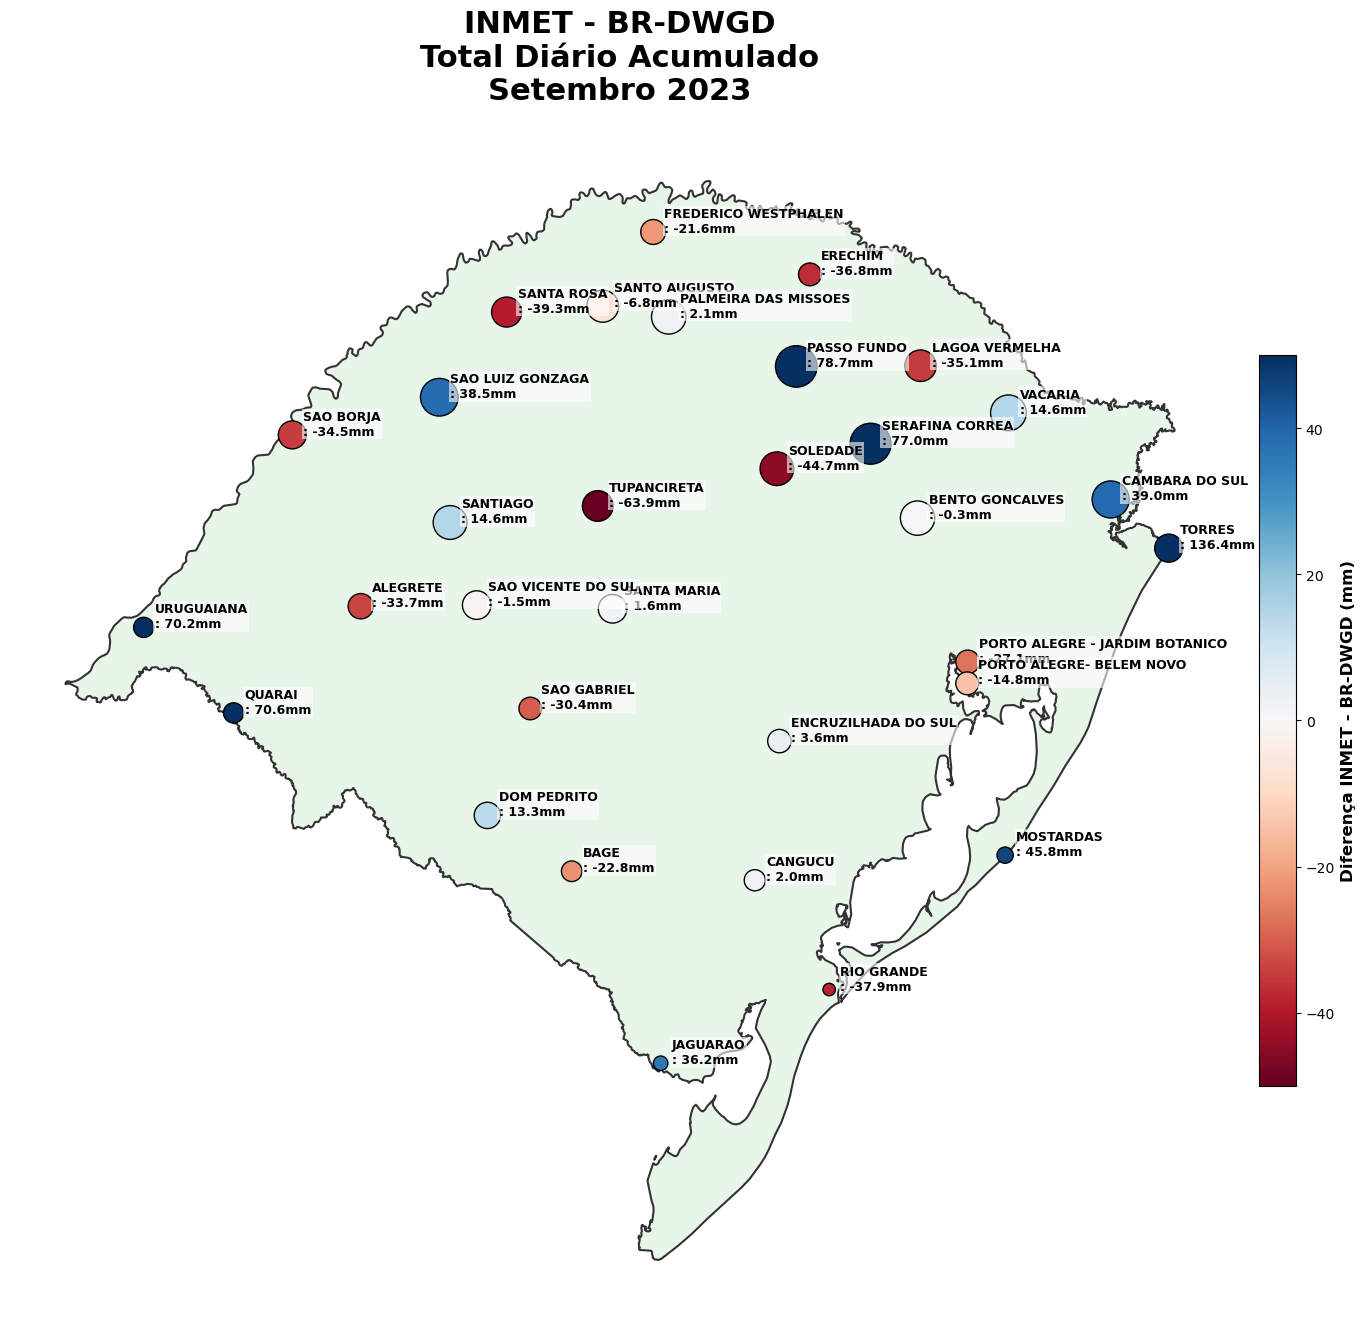

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url)
rs_mapa = brasil[brasil['sigla'] == 'RS']

fig, ax = plt.subplots(figsize=(15, 15))

rs_mapa.plot(ax=ax, facecolor='#E8F5E9', edgecolor='#333333', linewidth=1.5, zorder=1)

pontos = ax.scatter(
    df_mapa['Lon'],
    df_mapa['Lat'],
    s=df_mapa['Chuva_INMET'] * 3, # Tamanho pela chuva real
    c=df_mapa['Diferenca'],       # Cor pelo erro
    cmap='RdBu',                  # Vermelho (Xavier > INMET) / Azul (INMET > Xavier)
    edgecolors='black',
    linewidth=1,
    zorder=3,
    vmin=-50, # Centralizando a escala para o branco ser o erro zero
    vmax=50
)

for _, row in df_mapa.iterrows():
    ax.text(
        row['Lon'] + 0.08,
        row['Lat'],
        f"{row['Estacao']}\n: {row['Diferenca']:.1f}mm",
        fontsize=9,
        fontweight='bold',
        zorder=4,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
    )

ax.set_title(
    'INMET - BR-DWGD\nTotal Diário Acumulado\nSetembro 2023',
    fontsize=22, fontweight='bold', pad=20
)

cbar = plt.colorbar(pontos, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Diferença INMET - BR-DWGD (mm)', fontsize=12, fontweight='bold')

ax.axis('off')
plt.tight_layout()
plt.show()

mapa de diferença dos métodos apenas com xavier

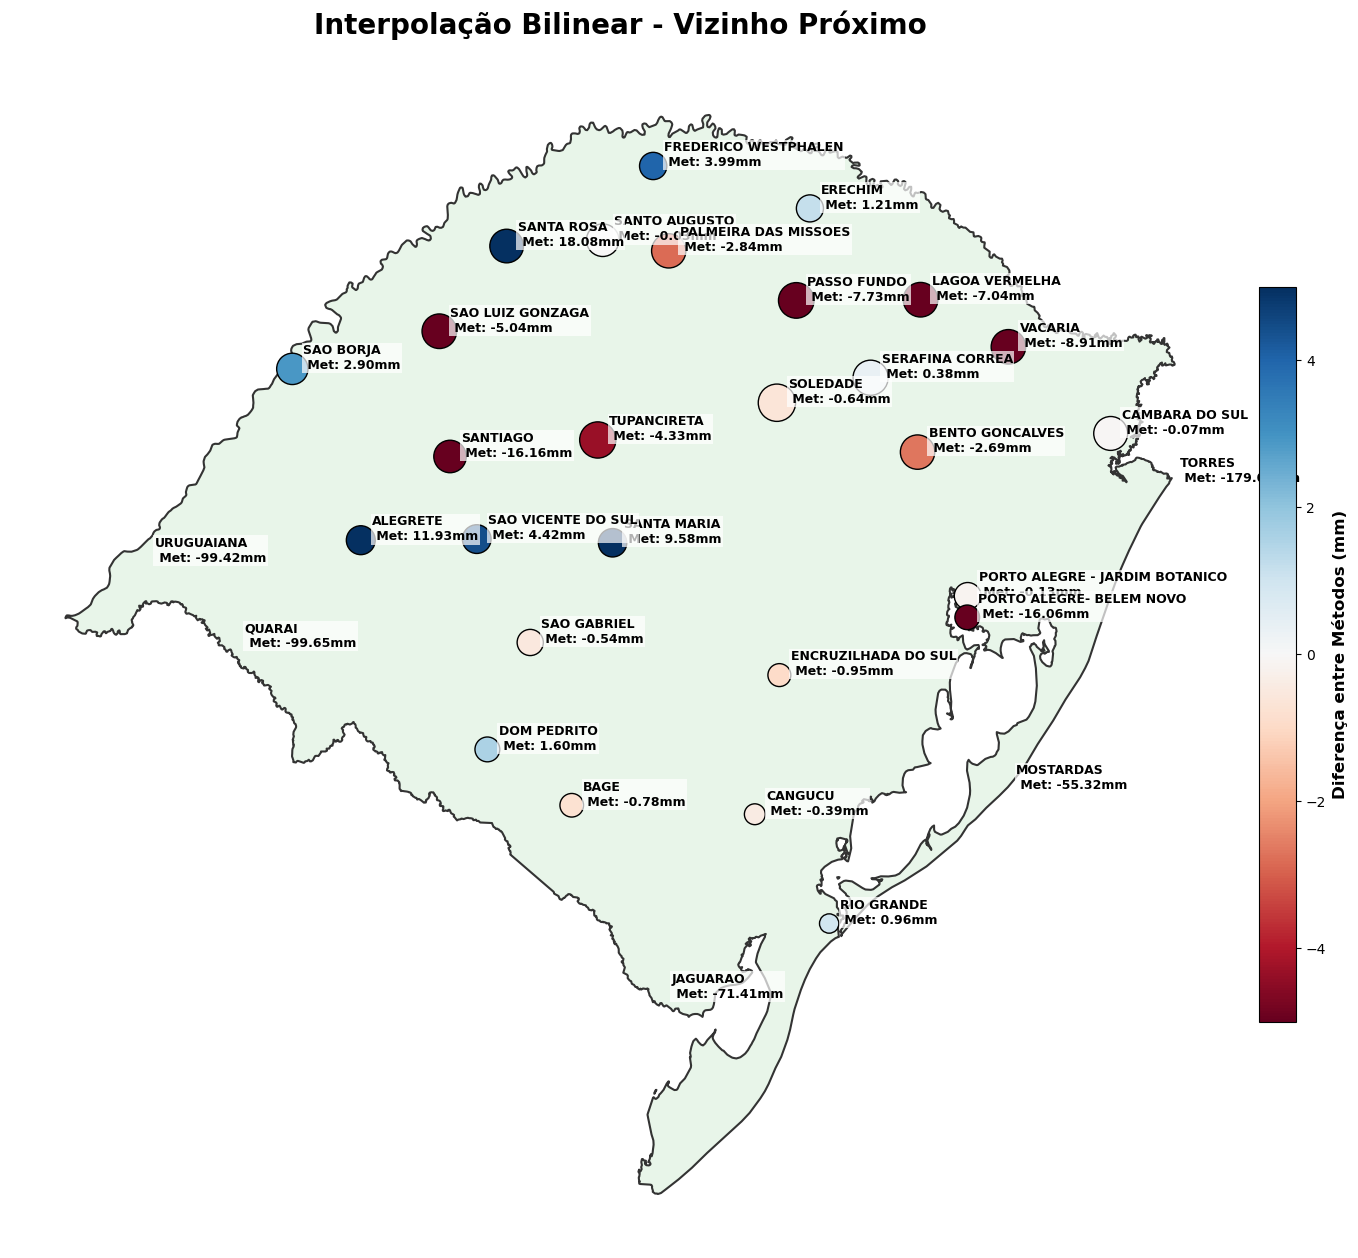

In [5]:
lista_comparativo_metodos = []

for index, row in df_aprovadas.iterrows():
    lat, lon = row['Latitude'], row['Longitude']

    # nearest (codigo antigo)
    v_nearest = ds.pr.sel(time=slice(data_inicio, data_fim)).sel(
        latitude=lat, longitude=lon, method='nearest'
    ).sum().values.item()

    # bilinear (codigo atualizado)
    v_bilinear = ds.pr.sel(time=slice(data_inicio, data_fim)).interp(
        latitude=lat, longitude=lon, method='linear'
    ).sum().values.item()

    lista_comparativo_metodos.append({
        'Estacao': row['Nome_Estacao'],
        'Lat': lat,
        'Lon': lon,
        'Nearest': v_nearest,
        'Bilinear': v_bilinear,
        'Dif_Metodos': v_bilinear - v_nearest
    })

df_metodos = pd.DataFrame(lista_comparativo_metodos)

fig, ax = plt.subplots(figsize=(15, 15))

rs_mapa.plot(ax=ax, facecolor='#E8F5E9', edgecolor='#333333', linewidth=1.5, zorder=1)

pontos = ax.scatter(
    df_metodos['Lon'],
    df_metodos['Lat'],
    s=df_metodos['Bilinear'] * 3,
    c=df_metodos['Dif_Metodos'],
    cmap='RdBu',
    edgecolors='black',
    linewidth=1,
    zorder=3,
    vmin=-5,
    vmax=5
)

for _, row in df_metodos.iterrows():
    ax.text(
        row['Lon'] + 0.08,
        row['Lat'],
        f"{row['Estacao']}\n Met: {row['Dif_Metodos']:.2f}mm",
        fontsize=9, fontweight='bold', zorder=4,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
    )

ax.set_title(
    'Interpolação Bilinear - Vizinho Próximo',
    fontsize=20, fontweight='bold', pad=20
)

cbar = plt.colorbar(pontos, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Diferença entre Métodos (mm)', fontsize=12, fontweight='bold')

ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
%pip install rioxarray

Note: you may need to restart the kernel to use updated packages.


In [7]:
print(df_mapa.columns)

Index(['Estacao', 'Lat', 'Lon', 'Chuva_INMET', 'Chuva_Xavier', 'Diferenca'], dtype='object')


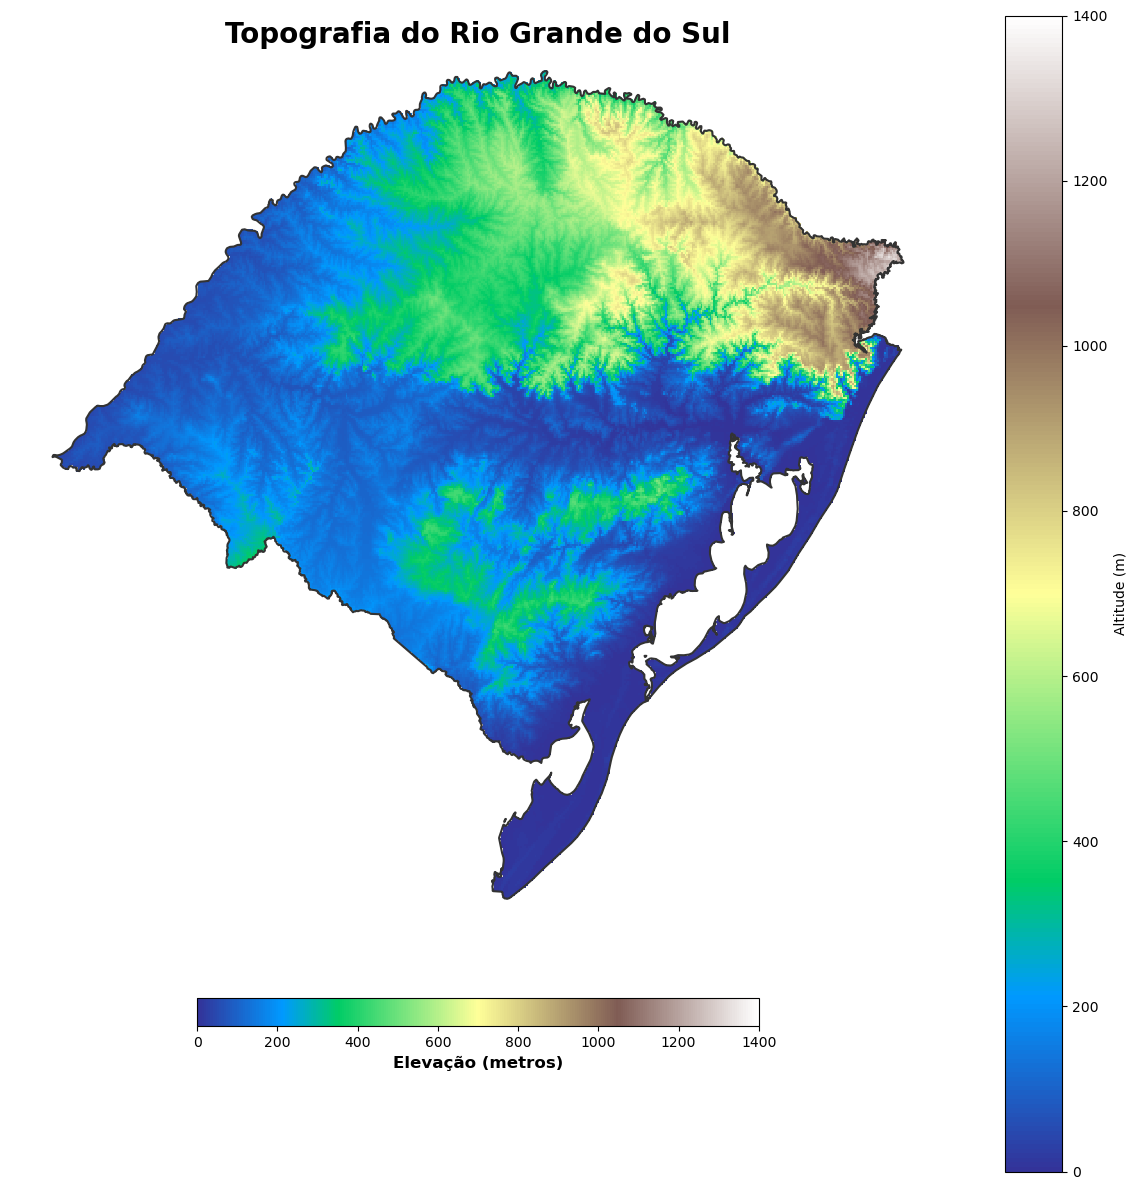

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray
import urllib.request
import copy

# 1. CARREGAMENTO DO CONTORNO DO RS
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

# 2. DOWNLOAD E PREPARAÇÃO DO RELEVO
#trecho [(-34.0):1:(-27.0)][(-58.0):1:(-49.0)] é a forma de pedir para o servidor da NOAA recortar os dados antes de você fazer o download. Isso se chama sintaxe OPeNDAP.
#A estrutura é sempre [(Início) : (Salto) : (Fim)]:
#[(-34.0):1:(-27.0)] (Latitude): Pede os dados do paralelo 34°S até o 27°S. Essa é a "altura" exata da caixa que engloba o Rio Grande do Sul.
#[(-58.0):1:(-49.0)] (Longitude): Pede os dados do meridiano 58°W até o 49°W. Essa é a "largura" da caixa.
#O número 1 no meio: É o stride (passo ou salto). Significa "traga 1 a 1", ou seja, faça o download de todos os pixels dessa área. Se você colocasse :2:, o servidor pularia um pixel sim e um não, te entregando um arquivo com metade da resolução (e metade do peso).
#Resumindo: essa linha evita que você baixe o relevo do planeta Terra inteiro (que tem gigabytes de tamanho) e baixa apenas um retângulo contendo o RS.

url_relevo = "https://coastwatch.pfeg.noaa.gov/erddap/griddap/etopo180.nc?altitude[(-34.0):1:(-27.0)][(-58.0):1:(-49.0)]"
nc_file = "relevo_rs.nc"

# Baixa o arquivo NetCDF da NOAA
urllib.request.urlretrieve(url_relevo, nc_file)

# Abre o dado e ajusta as coordenadas para o padrão do rioxarray
ds = xr.open_dataset(nc_file)
ds = ds.rename({'latitude': 'y', 'longitude': 'x'})
ds = ds.rio.write_crs("epsg:4326")

# Recorta o relevo usando o contorno do RS (o que fica de fora vira NaN)
relevo_rs = ds['altitude'].rio.clip(rs_mapa.geometry, rs_mapa.crs, drop=True)

# Limita valores mínimos a 0 (para não pegar profundidade da Lagoa/Oceano)
# O método .clip preserva os NaNs gerados fora das fronteiras
relevo_rs = relevo_rs.clip(min=0)

# 3. CONFIGURAÇÃO E PLOTAGEM
fig, ax = plt.subplots(figsize=(12, 12))

# Cria uma cópia do colormap 'terrain' e define que dados inválidos (NaN) sejam transparentes
cmap_terrain = copy.copy(plt.get_cmap('terrain'))
cmap_terrain.set_bad(color='none')

# Trecho corrigido da plotagem
relevo_plot = relevo_rs.plot.imshow(
    ax=ax, 
    cmap=cmap_terrain, 
    vmin=0, 
    vmax=1400,
    add_colorbar=True,
    cbar_kwargs={'label': 'Altitude (m)'}
)


# Plota o contorno do estado por cima
rs_mapa.plot(ax=ax, facecolor='none', edgecolor='#333333', linewidth=1.5, zorder=2)

# Adiciona a barra de cores do relevo na horizontal
cbar_terrain = plt.colorbar(relevo_plot, ax=ax, shrink=0.6, pad=0.05, orientation='horizontal')
cbar_terrain.set_label('Elevação (metros)', fontsize=12, fontweight='bold')

# Ajustes finais do gráfico
ax.set_title('Topografia do Rio Grande do Sul', fontsize=20, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()

plt.show()


In [12]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import copy

# Carregamento do contorno do RS
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

# Carregamento do relevo (ajuste o nome do arquivo conforme necessário)
ds_relevo = xr.open_dataset("relevo_rs.nc")
ds_relevo = ds_relevo.rename({'latitude': 'y', 'longitude': 'x'})
ds_relevo = ds_relevo.rio.write_crs("epsg:4326")

# Recorte do relevo para o estado
relevo_rs = ds_relevo['altitude'].rio.clip(rs_mapa.geometry, rs_mapa.crs, drop=True)
relevo_rs = relevo_rs.clip(min=0) # Remove valores abaixo do nível do mar

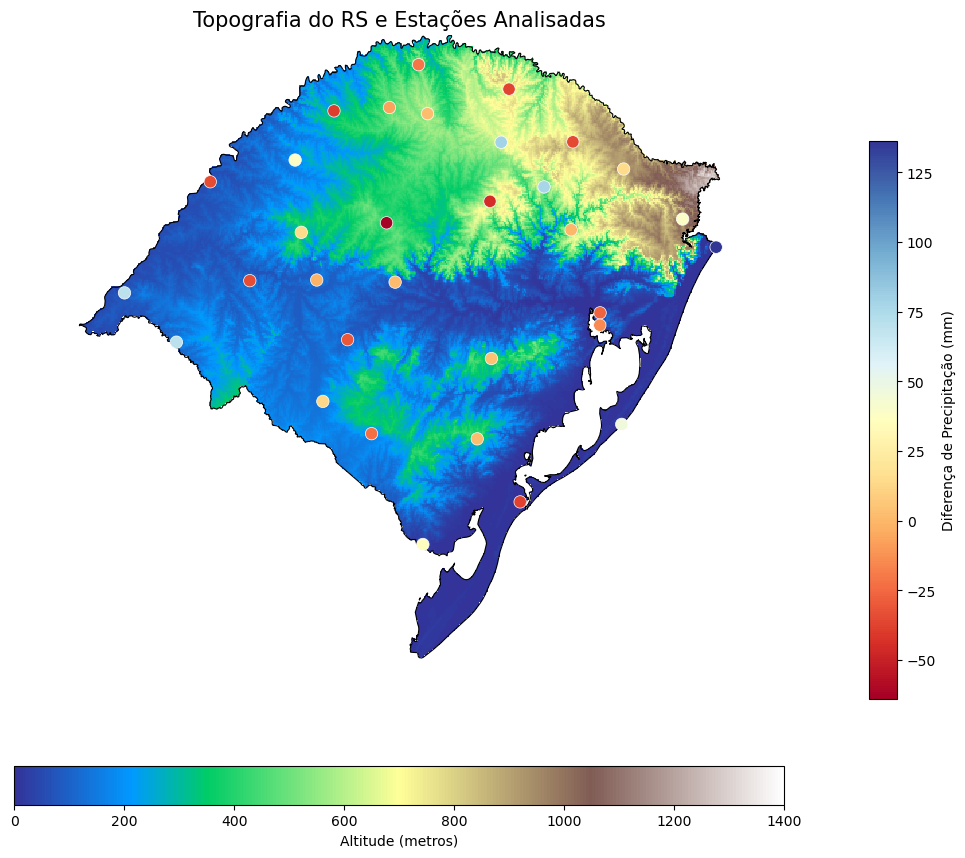

In [ ]:
# 2. CARREGAMENTO E RECORTE DO MAPA
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

# Abre o NetCDF e prepara as coordenadas
ds = xr.open_dataset(nc_file)
ds = ds.rename({'latitude': 'y', 'longitude': 'x'})
ds = ds.rio.write_crs("epsg:4326")

# Recorta o relevo exatamente no formato do RS
relevo_rs = ds['altitude'].rio.clip(rs_mapa.geometry, rs_mapa.crs, drop=True)
relevo_rs = relevo_rs.clip(min=0) # Remove o oceano

# 3. PLOTAGEM FINAL (Igual à sua imagem)
fig, ax = plt.subplots(figsize=(12, 10))

# Configura o mapa de cores da topografia
cmap_terrain = copy.copy(plt.get_cmap('terrain'))
cmap_terrain.set_bad(color='none') 

# Camada 1: Topografia (Fundo)
relevo_plot = relevo_rs.plot.imshow(
    ax=ax, 
    cmap=cmap_terrain, 
    vmin=0, 
    vmax=1400,
    add_colorbar=False
)

# Camada 2: Contorno do RS
rs_mapa.boundary.plot(ax=ax, color='black', linewidth=0.8, zorder=2)

# Camada 3: Seus dados (Pontos coloridos)
# Substitua 'df_mapa' pelo nome do seu DataFrame de resultados
if 'df_mapa' in locals():
    sc = ax.scatter(
        df_mapa['Lon'], 
        df_mapa['Lat'], 
        c=df_mapa['Diferenca'], # A cor baseada na diferença
        cmap='RdYlBu',          # Cores para chuva (Azul/Vermelho)
        s=80, 
        edgecolors='white', 
        linewidth=0.5,
        zorder=3
    )
    plt.colorbar(sc, label='Diferença de Precipitação (mm)', fraction=0.03, pad=0.04)

# Adiciona a barra de cores da altitude embaixo
cbar_top = plt.colorbar(relevo_plot, ax=ax, orientation='horizontal', fraction=0.05, pad=0.1)
cbar_top.set_label('Altitude (metros)')

ax.set_title("Topografia do RS e Estações Analisadas", fontsize=15)
ax.set_axis_off()

plt.show()

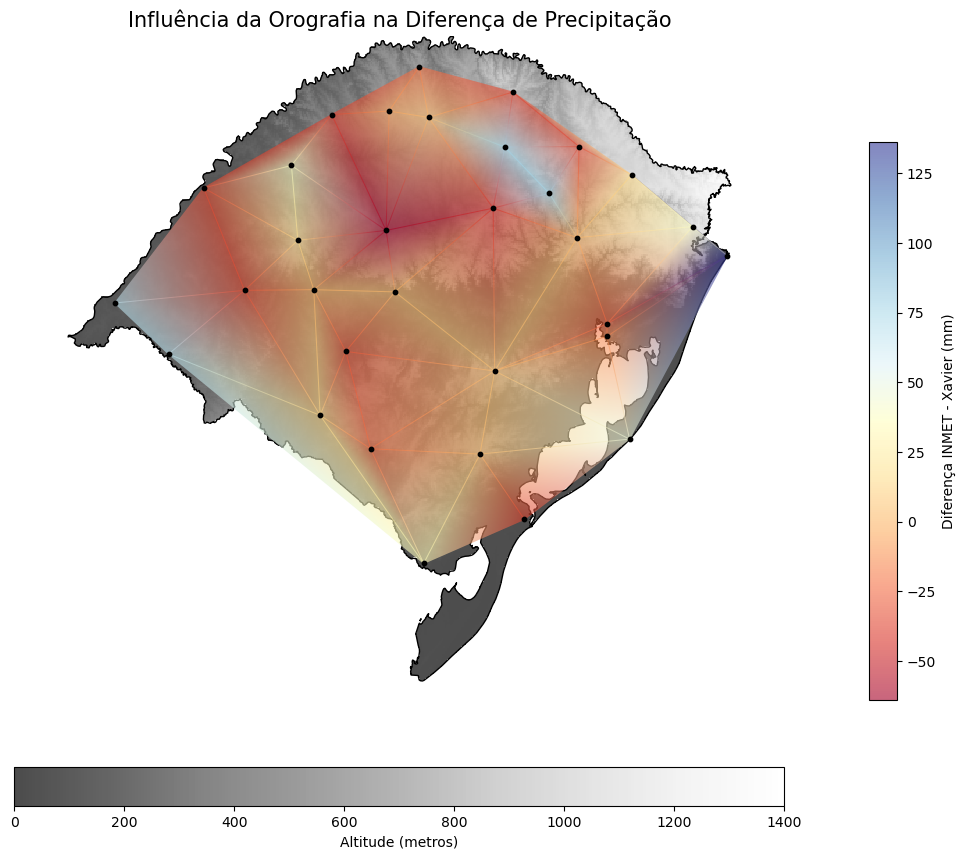

In [18]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import urllib.request
import copy
import os

# --- PASSO A: DOWNLOAD DO RELEVO ---
nc_file = "relevo_rs.nc"
if not os.path.exists(nc_file):
    print("Baixando arquivo de relevo... aguarde.")
    url_relevo = "https://pae-paha.pacioos.hawaii.edu/erddap/griddap/etopo1.nc?altitude[(-34.0):1:(-27.0)][(-58.0):1:(-49.0)]"
    urllib.request.urlretrieve(url_relevo, nc_file)
    print("Download concluído!")

# --- PASSO B: CARREGAMENTO E RECORTE ---
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

ds = xr.open_dataset(nc_file)
ds = ds.rename({'latitude': 'y', 'longitude': 'x'})
ds = ds.rio.write_crs("epsg:4326")

# Recorta o relevo no formato do RS
relevo_rs = ds['altitude'].rio.clip(rs_mapa.geometry, rs_mapa.crs, drop=True)
relevo_rs = relevo_rs.clip(min=0)

# --- PASSO C: PLOTAGEM ---
fig, ax = plt.subplots(figsize=(12, 10))

# Mapa de cores para o relevo (tons de cinza para destacar a chuva)
cmap_terrain = copy.copy(plt.get_cmap('Greys_r')) 
cmap_terrain.set_bad(color='none') 

# 1. Desenha o Relevo
relevo_plot = relevo_rs.plot.imshow(
    ax=ax, 
    cmap=cmap_terrain, 
    vmin=0, 
    vmax=1400,
    add_colorbar=False,
    alpha=0.7
)

# 2. Desenha o Contorno do Estado
rs_mapa.boundary.plot(ax=ax, color='black', linewidth=1, zorder=2)

# 3. Desenha os seus dados (Diferença de Chuva)
# Usando tripcolor para o efeito de "mancha" (heatmap) da sua imagem
if 'df_mapa' in locals():
    # Cria a superfície colorida
    chuva_plot = ax.tripcolor(
        df_mapa['Lon'], 
        df_mapa['Lat'], 
        df_mapa['Diferenca'],
        cmap='RdYlBu', # Azul para positivo, Vermelho para negativo
        shading='gouraud',
        alpha=0.6,
        zorder=3
    )
    
    # Adiciona os pontos das estações em preto (pequenos)
    ax.scatter(df_mapa['Lon'], df_mapa['Lat'], color='black', s=10, zorder=4)
    
    # Barra de cores da chuva
    plt.colorbar(chuva_plot, label='Diferença INMET - Xavier (mm)', fraction=0.03, pad=0.04)

# Barra de cores da altitude (opcional)
cbar_top = plt.colorbar(relevo_plot, ax=ax, orientation='horizontal', fraction=0.05, pad=0.07)
cbar_top.set_label('Altitude (metros)')

ax.set_title("Influência da Orografia na Diferença de Precipitação", fontsize=15)
ax.set_axis_off()

plt.show()